In [10]:
from langgraph.graph import StateGraph, START, END
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv
from typing import TypedDict, Annotated
from pydantic import BaseModel, Field
import operator

In [4]:
load_dotenv()
model = ChatGoogleGenerativeAI(model='gemini-3.5-flash')

In [5]:
class EvaluationSchema(BaseModel):
    feedback: str = Field(description="Detailed feedback for the Essay.")
    score: int = Field(description="Score out of 10", ge=0, le=10)

In [6]:
structured_model = model.with_structured_output(EvaluationSchema)

In [7]:
essay = """
The integration of Artificial Intelligence (AI) into Pakistan’s socio-economic landscape is rapidly transitioning from a distant future vision to an active digital revolution. As global industries pivot toward automation, intelligent data processing, and predictive modeling, Pakistan stands at a critical juncture. With a massive youth population, a expanding freelance economy, and increasing technological infrastructure, the rise of AI in Pakistan holds transformative potential alongside structural challenges.

At the forefront of this technological shift is Pakistan’s booming IT sector and freelance workforce. Recognized as one of the top global destinations for freelance software development and digital services, Pakistani engineers and tech workers are rapidly adopting AI tools to enhance productivity, automate complex code generation, and deliver intelligent solutions to international clients. Moreover, local startups are leveraging AI to solve indigenous problems. In financial technology (fintech), AI algorithms are enabling credit scoring for unbanked populations; in logistics, predictive analytics are optimizing supply chains; and in e-commerce, AI-driven recommendation engines are personalizing consumer experiences.

The public and healthcare sectors are also beginning to realize the benefits of artificial intelligence. Educational institutions, particularly leading universities, are expanding research in machine learning, computer vision, and natural language processing (NLP)—with a growing emphasis on Urdu NLP to make technology accessible to local communities. In healthcare, preliminary AI applications in diagnostic imaging and telemedicine are helping bridge the gap between urban medical centers and underserved rural areas, allowing for faster and more accurate preliminary diagnoses.
"""

In [8]:
prompt = f'Evaluate the language quality of the following essay and provide a feedback and assign a socre out of 10 \n {essay}'
structured_model.invoke(prompt)

Direct use of automatic function calling (AFC) in Models.generate_content is not recommended. Instead, we recommend to use AFC in Chat.send_message. Similarly, direct use of AFC in Models.generate_content_stream is not recommended. Instead, we recommend to use AFC in Chat.send_message_stream.


EvaluationSchema(feedback="The essay exhibits excellent language quality, characterized by a sophisticated vocabulary, precise terminology, and flawless grammatical construction. The sentence structures are varied and flow logically, maintaining a professional and academic tone throughout. Terms like 'indigenous problems,' 'critical juncture,' and 'predictive modeling' are used accurately, enhancing the depth of the discussion. The text is highly coherent and effectively conveys the integration of AI in Pakistan's socio-economic sectors. To improve further, the essay could benefit from a concluding paragraph to synthesize the main points and provide a balanced summary of the 'structural challenges' mentioned in the introduction.", score=9)

In [11]:
class ExamState(TypedDict):
    essay: str
    language: str
    analysis_feedback: str
    clarity_feedback: str
    overall_feedback: str
    inividual_score: Annotated[list[int], operator.add]
    avg_score: float
    

In [13]:
def evaluate_language(state: ExamState):

    prompt = f'Evaluate the language quality of the following essay and provide a feedback and assign a socre out of 10 \n {state['essay']}'
    output = structured_model.invoke(prompt)

    return {'language_feedback': output.feedback, 'indiviual_score': [output.score]}

In [17]:
def evaluate_analysis(state: ExamState):

    prompt = f'Evaluate the depth of the Analysis of the following essay and provide a feedback and assign a socre out of 10 \n {state['essay']}'
    output = structured_model.invoke(prompt)

    return {'analysis_feedback': output.feedback, 'indiviual_score': [output.score]}

In [18]:
def evaluate_thought(state: ExamState):

    prompt = f'Evaluate the clarity of thought of the following essay and provide a feedback and assign a socre out of 10 \n {state['essay']}'
    output = structured_model.invoke(prompt)

    return {'clarity_feedback': output.feedback, 'indiviual_score': [output.score]}

In [19]:
def final_evaluate(state: ExamState):

    # summary feedback
    prompt = f'Based on the following feedbacks create a summarized feedback \n language feedback - {state ["language_feedback"]} \n depth of analysis feedback = {state['analysis_feedback']} \n clarity of thought feedback {state["clarity_feedback"]}'

    overall_feedback = model.invoke(prompt).content

    # avg calculate
    avg_score = sum(state["inividual_score"])/len(state['inividual_score'])

    return {'overall_feedback': overall_feedback, 'avg_score': avg_score}

In [20]:
graph = StateGraph(ExamState)

graph.add_node('evaluate_language', evaluate_language)
graph.add_node('evaluate_analysis', evaluate_analysis)
graph.add_node('evaluate_thought', evaluate_thought)
graph.add_node('final_evaluate', final_evaluate)


graph.add_edge(START, 'evaluate_language')
graph.add_edge(START, 'evaluate_analysis')
graph.add_edge(START, 'evaluate_thought')

graph.add_edge('evaluate_language', 'final_evaluate')
graph.add_edge('evaluate_analysis', 'final_evaluate')
graph.add_edge('evaluate_thought', 'final_evaluate')

graph.add_edge('final_evaluate', END)

workflow = graph.compile()

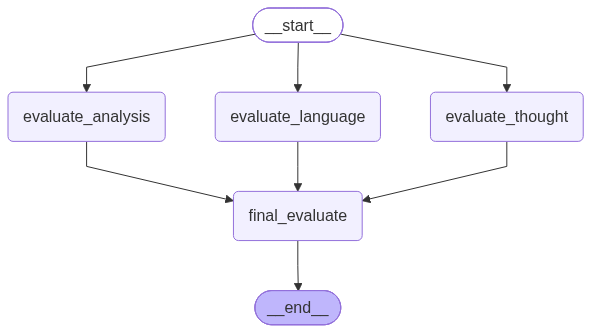

In [21]:
workflow

In [ ]:
initial_state = {
    'essay': essay 
}
workflow.invoke(initial_state)

KeyError: 'language_feedback'